# 机器学习实验一：bank 数据任务代码框架

本 Notebook 供实验一使用，建议按顺序完成：

1. 读取 `bank_train.csv` 和 `bank_test.csv`
2. 做基础数据检查与预处理
3. 完成任务一：使用 `sklearn` 构建决策树
4. 完成任务二：手写 ID3
5. 完成选做题（可选）
6. 在实验报告中整理结果与分析

> 注意：请根据实验要求补全 `TODO` 部分。


## 0. 导入库


In [29]:
from pathlib import Path
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

LABEL_COL = "approve"
RANDOM_STATE = 42

## 1. 读取数据


In [30]:
train_path = Path("bank_train.csv")
test_path = Path("bank_test.csv")

if not train_path.exists() or not test_path.exists():
    raise FileNotFoundError("请确认当前文件夹中存在 bank_train.csv 和 bank_test.csv")

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("训练集大小：", train_df.shape)
print("测试集大小：", test_df.shape)
train_df.head()


训练集大小： (800, 9)
测试集大小： (200, 9)


,nameid,profession,education,house_loan,car_loan,married,child,revenue,approve
0,1,5,1,0,0,1,1,8204,1
1,2,3,1,1,1,0,0,5674,0
2,3,2,3,1,0,1,0,10634,1
3,4,2,2,0,0,0,0,43551,1
4,5,4,2,0,1,0,1,14065,0


## 2. 数据检查与基础预处理

这一步建议完成：

- 查看字段名是否正确
- 检查是否有缺失值
- 查看标签 `approve` 的分布
- 删除编号列 `nameid`


In [31]:
print("训练集字段：", train_df.columns.tolist())
print("测试集字段：", test_df.columns.tolist())

print("\n训练集缺失值统计：")
print(train_df.isnull().sum())

print("\n测试集缺失值统计：")
print(test_df.isnull().sum())

print("\n训练集标签分布：")
print(train_df["approve"].value_counts())

# 删除不参与建模的编号列
train_base = train_df.drop(columns=["nameid"]).copy()
test_base = test_df.drop(columns=["nameid"]).copy()


feature_cols = [c for c in train_base.columns if c != LABEL_COL]

print("\n特征列：", feature_cols)


训练集字段： ['nameid', 'profession', 'education', 'house_loan', 'car_loan', 'married', 'child', 'revenue', 'approve']
测试集字段： ['nameid', 'profession', 'education', 'house_loan', 'car_loan', 'married', 'child', 'revenue', 'approve']

训练集缺失值统计：
nameid        0
profession    0
education     0
house_loan    0
car_loan      0
married       0
child         0
revenue       0
approve       0
dtype: int64

测试集缺失值统计：
nameid        0
profession    0
education     0
house_loan    0
car_loan      0
married       0
child         0
revenue       0
approve       0
dtype: int64

训练集标签分布：
approve
1    518
0    282
Name: count, dtype: int64

特征列： ['profession', 'education', 'house_loan', 'car_loan', 'married', 'child', 'revenue']


# 3. 任务一：使用 sklearn 构建决策树

建议流程：

- 构造 `X / y`
- 从训练集中划分训练子集和验证集
- 至少比较 3 组参数
- 用验证集选择较优参数
- 用测试集做最终评估
- 绘制决策树


## 3.1 构造 `X / y`


In [32]:
# TODO：完成任务一所需的 X / y 构造
# 提示：sklearn 决策树可以直接使用 revenue 的连续数值

X_train_all = train_base.drop(columns=["approve"]).copy()
y_train_all = train_base["approve"].copy()

X_test = test_base.drop(columns=["approve"]).copy()
y_test = test_base["approve"].copy()


## 3.2 划分训练集 / 验证集


In [33]:
# TODO：从训练集内部再划分出验证集
# 提示：可以使用 train_test_split，也可以使用交叉验证

X_train, X_val, y_train, y_val  = train_test_split(
    X_train_all,
    y_train_all,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_train_all,
)


## 3.3 参数设置与训练


In [34]:
# TODO：至少记录 3 组参数
param_list = [
     {"name": "Model_A_gini_depth3", "criterion": "gini", "max_depth": 3, "min_samples_split": 2, "min_samples_leaf": 1},
     {"name": "Model_B_gini_depth4", "criterion": "entropy", "max_depth": 4, "min_samples_split": 2, "min_samples_leaf": 1},
     {"name": "Model_C_gini_depth5_leaf2", "criterion": "entropy", "max_depth": 5, "min_samples_split": 4, "min_samples_leaf": 3},
]

results = []

for params in param_list:
    clf = DecisionTreeClassifier(
        criterion=params["criterion"],
        max_depth=params["max_depth"],
        min_samples_split=params["min_samples_split"],
        min_samples_leaf=params["min_samples_leaf"],
        random_state=RANDOM_STATE,
    )
    

    # TODO：训练模型
    clf.fit(X_train,y_train)
    # TODO：在验证集上预测
    y_val_pred = clf.predict(X_val)
    


    # TODO：计算 Accuracy / Precision / Recall / F1
    # 可参考 accuracy_score、precision_score、recall_score、f1_score
    results.append({
        "model": params["name"],
        "criterion": params["criterion"],
        "max_depth": params["max_depth"],
        "min_samples_split": params["min_samples_split"],
        "min_samples_leaf": params["min_samples_leaf"],
        "accuracy": accuracy_score(y_val, y_val_pred),
        "precision": precision_score(y_val, y_val_pred, pos_label=1),
        "recall": recall_score(y_val, y_val_pred, pos_label=1),
        "f1": f1_score(y_val, y_val_pred, pos_label=1),
    })

# TODO：显示每组参数的训练结果

results_df = pd.DataFrame(results)
results_df

,model,criterion,max_depth,min_samples_split,min_samples_leaf,accuracy,precision,recall,f1
0,Model_A_gini_depth3,gini,3,2,1,0.80625,0.770370,1.000000,0.870293
1,Model_B_gini_depth4,entropy,4,2,1,0.83125,0.808000,0.971154,0.882096
2,Model_C_gini_depth5_leaf2,entropy,5,4,3,0.80625,0.806723,0.923077,0.860987


## 3.4 选择参数并在测试集上评估


In [37]:
# TODO：根据验证集结果选择较优参数
best_params = next(p for p in param_list if p["name"] == "Model_B_gini_depth4")

# TODO：重新训练最终模型
final_clf = DecisionTreeClassifier(
    criterion=best_params["criterion"],
    max_depth=best_params["max_depth"],
    min_samples_split=best_params["min_samples_split"],
    min_samples_leaf=best_params["min_samples_leaf"],
    random_state=RANDOM_STATE,
)
final_clf.fit(X_train_all, y_train_all)

# TODO：测试集预测
y_test_pred = final_clf.predict(X_test)

# TODO：计算并打印测试集上的 Accuracy / Precision / Recall / F1
print("测试集最终评估结果：")
print(f"Accuracy : {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred, pos_label=1):.4f}")
print(f"Recall   : {recall_score(y_test, y_test_pred, pos_label=1):.4f}")
print(f"F1-score : {f1_score(y_test, y_test_pred, pos_label=1):.4f}")

print("\n分类报告：")
print(classification_report(
    y_test,
    y_test_pred,
    target_names=["benign", "malignant"],
))


测试集最终评估结果：
Accuracy : 0.9900
Precision: 1.0000
Recall   : 0.9880
F1-score : 0.9939

分类报告：
              precision    recall  f1-score   support

      benign       0.94      1.00      0.97        34
   malignant       1.00      0.99      0.99       166

    accuracy                           0.99       200
   macro avg       0.97      0.99      0.98       200
weighted avg       0.99      0.99      0.99       200



## 3.5 混淆矩阵与决策树可视化


[[ 34   0]
 [  2 164]]


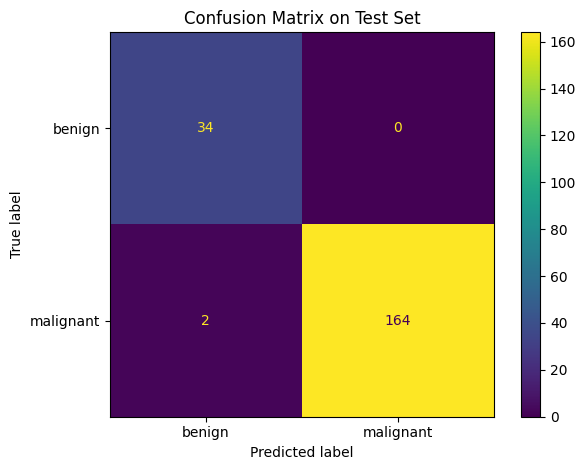

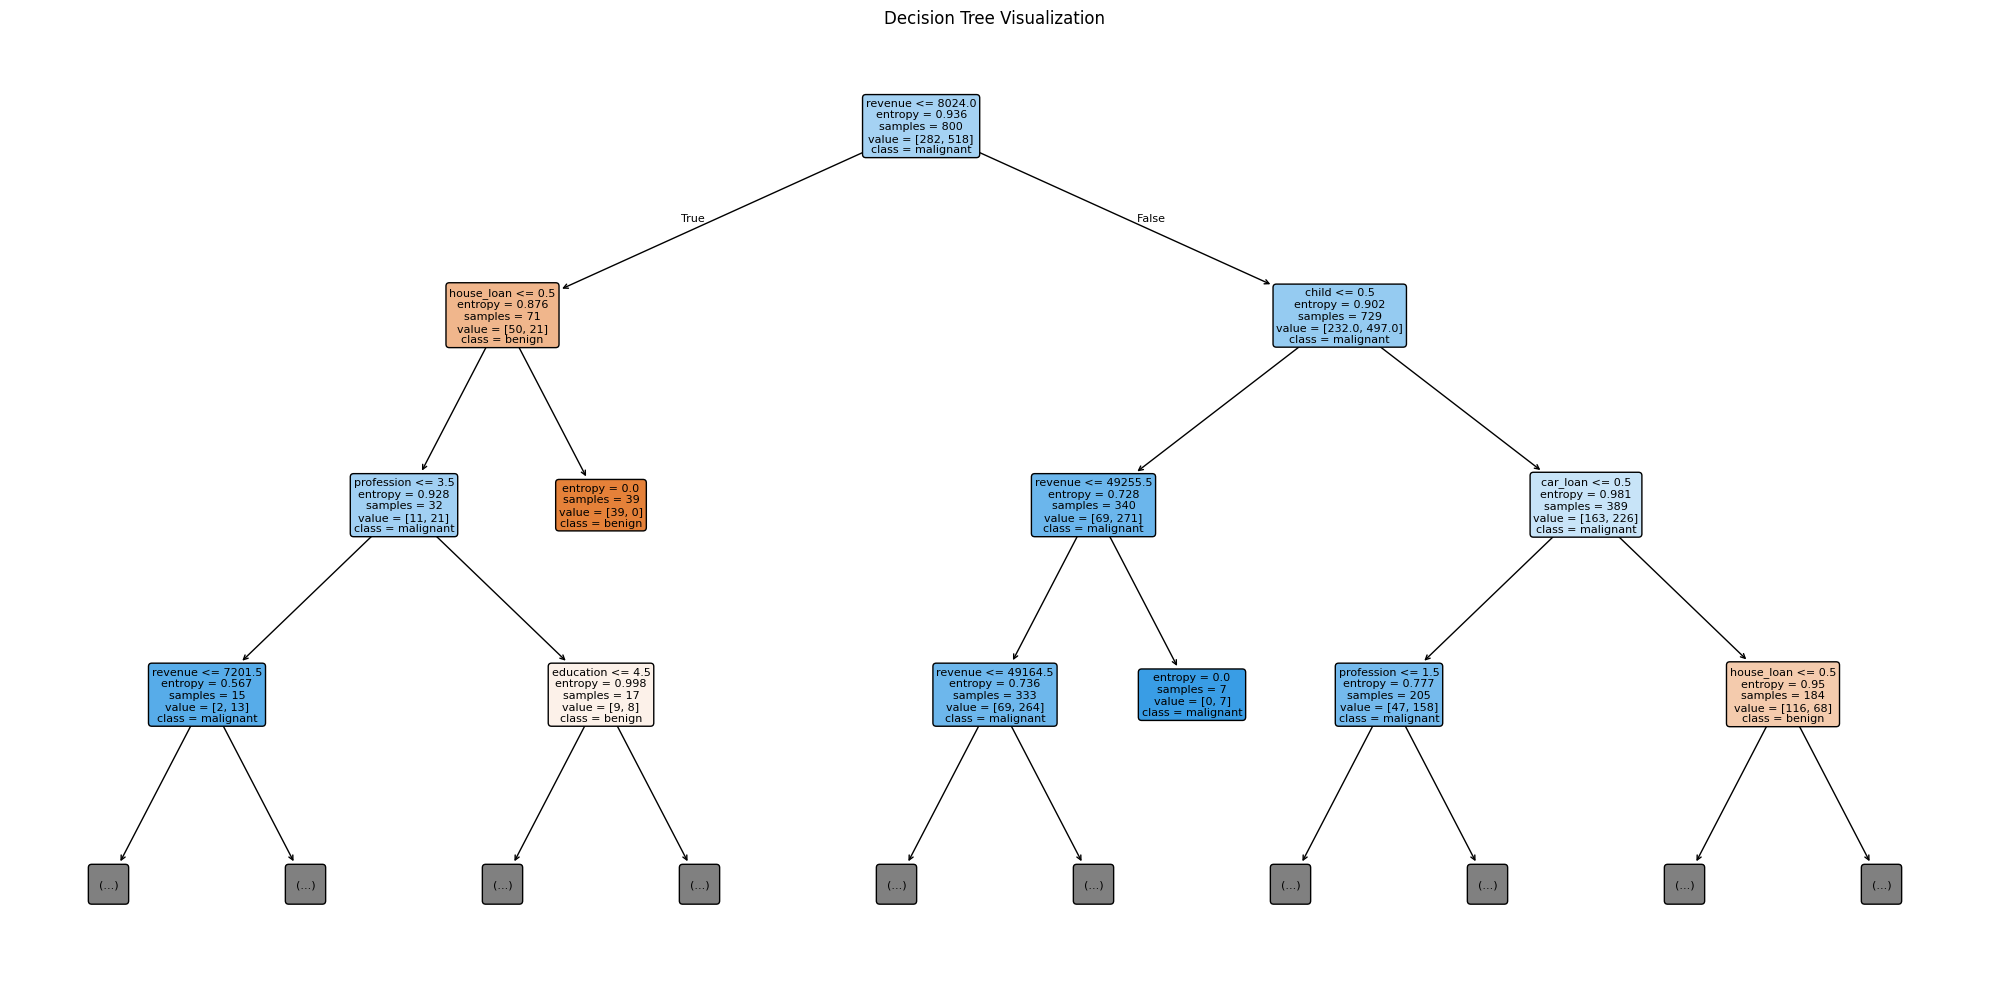

In [40]:
# TODO：绘制混淆矩阵
# cm = confusion_matrix(...)
# disp = ConfusionMatrixDisplay(...)
# disp.plot()
cm = confusion_matrix(y_test, y_test_pred)
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["benign", "malignant"],
)
disp.plot()
plt.title("Confusion Matrix on Test Set")
plt.tight_layout()
plt.savefig("confusion_matrix2.png", dpi=200)
plt.show()
# TODO：绘制决策树，并保存为 png
# plt.figure(figsize=(...))
# plot_tree(...)
# plt.savefig("task1_tree.png", dpi=200)
plt.figure(figsize=(20, 10))
plot_tree(
    final_clf,
    feature_names=train_base.columns,
    class_names=["benign", "malignant"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8,
)
plt.title("Decision Tree Visualization")
plt.tight_layout()
plt.savefig("decision_tree2.png", dpi=200)
plt.show()


# 4. 任务二：手写 ID3

任务二统一采用：

- 离散特征、多叉树版 ID3
- `revenue` 需要先离散化
- 预测时要处理未见过属性值（fallback）


## 4.1 `revenue` 离散化


In [ ]:
# 建议：给任务二单独准备一份数据，避免和任务一互相影响
train_id3 = train_base.copy()
test_id3 = test_base.copy()

# TODO：按实验要求对 revenue 进行离散化
bins = [-np.inf, 10000, 20000, 30000, 40000, np.inf]
train_id3["revenue"] = ...
test_id3["revenue"] = ...


## 4.2 核心函数骨架


In [ ]:
def calc_entropy(data, label=LABEL_COL):
    # TODO：计算数据集熵
    pass


def calc_info_gain(data, feature, label=LABEL_COL):
    # TODO：计算某个特征的信息增益
    pass


def majority_class(data, label=LABEL_COL):
    # TODO：返回当前数据集中的多数类
    pass


def build_tree(data, features, label=LABEL_COL, max_depth=None, current_depth=0):
    # TODO：递归构建多叉决策树
    # 基础任务：可以暂时不使用 max_depth 和 current_depth
    # 选做题：使用 max_depth 和 current_depth 实现预剪枝
    # 当 max_depth is not None 且 current_depth >= max_depth 时，停止继续划分，返回当前多数类
    # 建议在内部节点保存 majority，用于预测时的 fallback
    pass


def predict_one(tree, sample):
    # TODO：对单个样本预测
    # 如果 sample 在当前节点上的取值未出现过，则返回 tree["majority"]
    pass


def predict(tree, data):
    # TODO：批量预测
    pass


## 4.3 模型训练与测试集评估


In [ ]:
# TODO：准备任务二的训练特征列表
id3_features = [c for c in train_id3.columns if c != LABEL_COL]

# TODO：构建决策树
tree = ...

# TODO：在测试集上预测
y_true = ...
y_pred = ...

# TODO：手写计算 Accuracy / Precision / Recall / F1
# 建议先展示 TP、TN、FP、FN，再计算指标
...


## 4.4 选做题：预剪枝（可选）

选做题思路：

- 在 4.2 的 `build_tree` 函数中，已经预留了 `max_depth` 和 `current_depth`
- 基础任务中可以保持 `max_depth=None`，表示不限制树的最大深度
- 当 `max_depth is not None` 且 `current_depth >= max_depth` 时停止递归，返回当前多数类
- 递归构建子树时，将 `current_depth + 1` 传入下一层
- 比较 `max_depth = 3, 5, 10, None` 的结果


In [2]:
# TODO：选做题实验位置
# 你可以在这里调用带 max_depth 的 build_tree
# 并比较不同深度下的 Precision / Recall / F1
